In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

matches = pd.read_csv("../Data/cleaned/WorldCupMatches_C.csv")

matches.head()


,Year,Datetime,Stage,Stadium,City,HomeTeamName,HomeTeamGoals,AwayTeamGoals,AwayTeamName,Winconditions,...,HalftimeAwayGoals,Referee,Assistant1,Assistant2,RoundID,MatchID,HomeTeamInitials,AwayTeamInitials,MatchDate,MatchTime
0,1930,1930-07-13 15:00:00,Group 1,Pocitos,Montevideo,France,4,1,Mexico,,...,0,LOMBARDI Domingo (URU),CRISTOPHE Henry (BEL),REGO Gilberto (BRA),201,1096,FRA,MEX,1930-07-13,15:00:00
1,1930,1930-07-13 15:00:00,Group 4,Parque Central,Montevideo,United States,3,0,Belgium,,...,0,MACIAS Jose (ARG),MATEUCCI Francisco (URU),WARNKEN Alberto (CHI),201,1090,USA,BEL,1930-07-13,15:00:00
2,1930,1930-07-14 12:45:00,Group 2,Parque Central,Montevideo,Yugoslavia,2,1,Brazil,,...,0,TEJADA Anibal (URU),VALLARINO Ricardo (URU),BALWAY Thomas (FRA),201,1093,YUG,BRA,1930-07-14,12:45:00
3,1930,1930-07-14 14:50:00,Group 3,Pocitos,Montevideo,Romania,3,1,Peru,,...,0,WARNKEN Alberto (CHI),LANGENUS Jean (BEL),MATEUCCI Francisco (URU),201,1098,ROU,PER,1930-07-14,14:50:00
4,1930,1930-07-15 16:00:00,Group 1,Parque Central,Montevideo,Argentina,1,0,France,,...,0,REGO Gilberto (BRA),SAUCEDO Ulises (BOL),RADULESCU Constantin (ROU),201,1085,ARG,FRA,1930-07-15,16:00:00


In [2]:
# EDA Task 1 - Total Goals Scored By Tournament Year

matches['TotalGoals'] = (matches['HomeTeamGoals'] + matches['AwayTeamGoals'])

goalsByYear = matches.groupby('Year')['TotalGoals'].sum()

goalsByYear

Year
1930     70
1934     70
1938     84
1950     88
1954    140
1958    126
1962     89
1966     89
1970     95
1974     97
1978    102
1982    146
1986    132
1990    115
1994    141
1998    171
2002    161
2006    147
2010    145
2014    206
Name: TotalGoals, dtype: int64

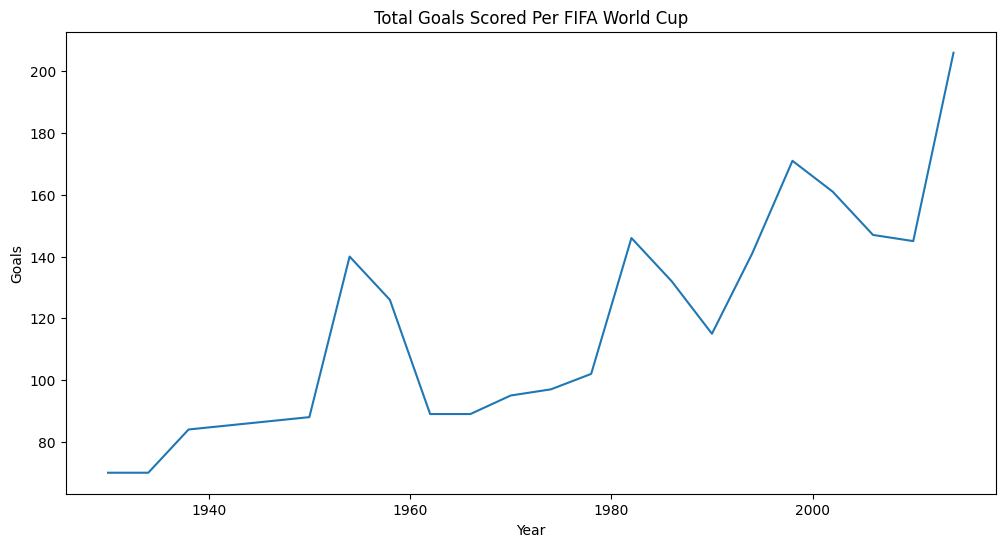

In [5]:
plt.figure(figsize=(12,6))

plt.plot(goalsByYear.index, goalsByYear.values)

plt.title('Total Goals Scored Per FIFA World Cup')
plt.xlabel('Year')
plt.ylabel('Goals')

plt.show()

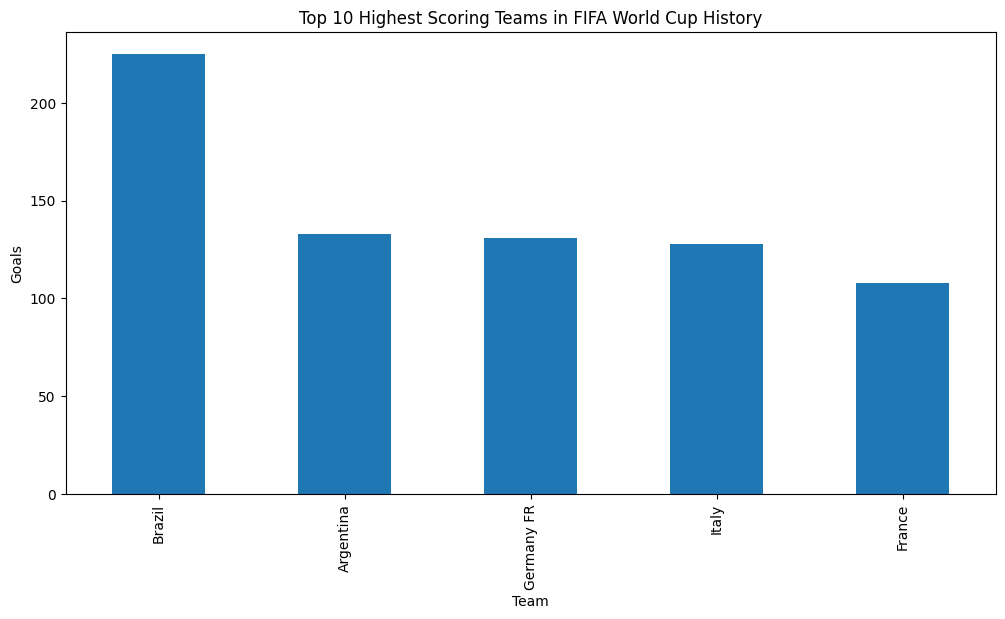

In [7]:
# EDA TASK 2 — Top 10 Highest Scoring Teams

homeGoals = matches.groupby('HomeTeamName')['HomeTeamGoals'].sum()
awayGoals = matches.groupby('AwayTeamName')['AwayTeamGoals'].sum()

totalTeamGoals = homeGoals.add(awayGoals, fill_value=0)

topTeams = totalTeamGoals.sort_values(ascending=False).head(5)

topTeams

plt.figure(figsize=(12,6))

topTeams.plot(kind='bar')

plt.title('Top 10 Highest Scoring Teams in FIFA World Cup History')
plt.xlabel('Team')
plt.ylabel('Goals')

plt.show()

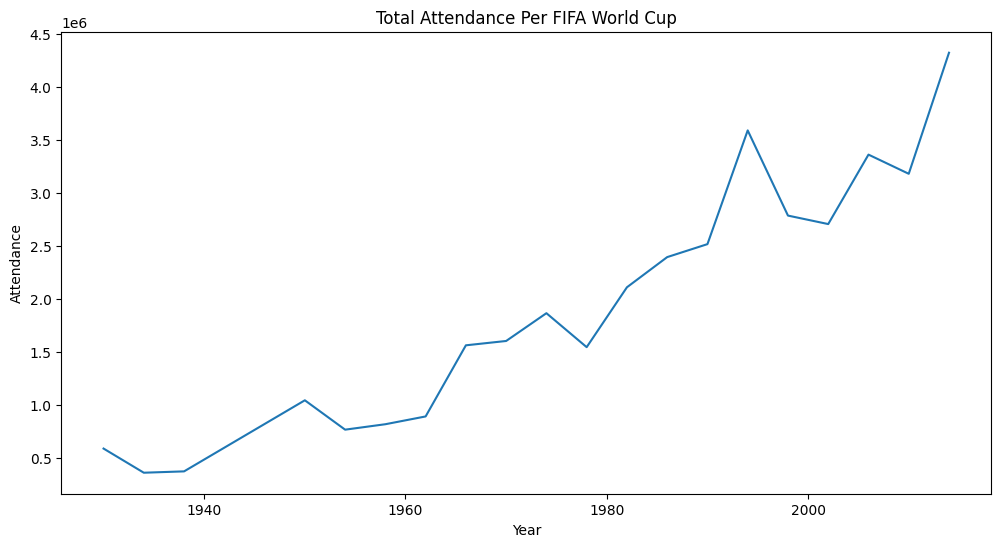

In [13]:
attendanceByYear = matches.groupby('Year')['Attendance'].sum()
attendanceByYear

plt.figure(figsize=(12,6))

plt.plot(attendanceByYear.index, attendanceByYear.values)

plt.title('Total Attendance Per FIFA World Cup')
plt.xlabel('Year')
plt.ylabel('Attendance')

plt.show()

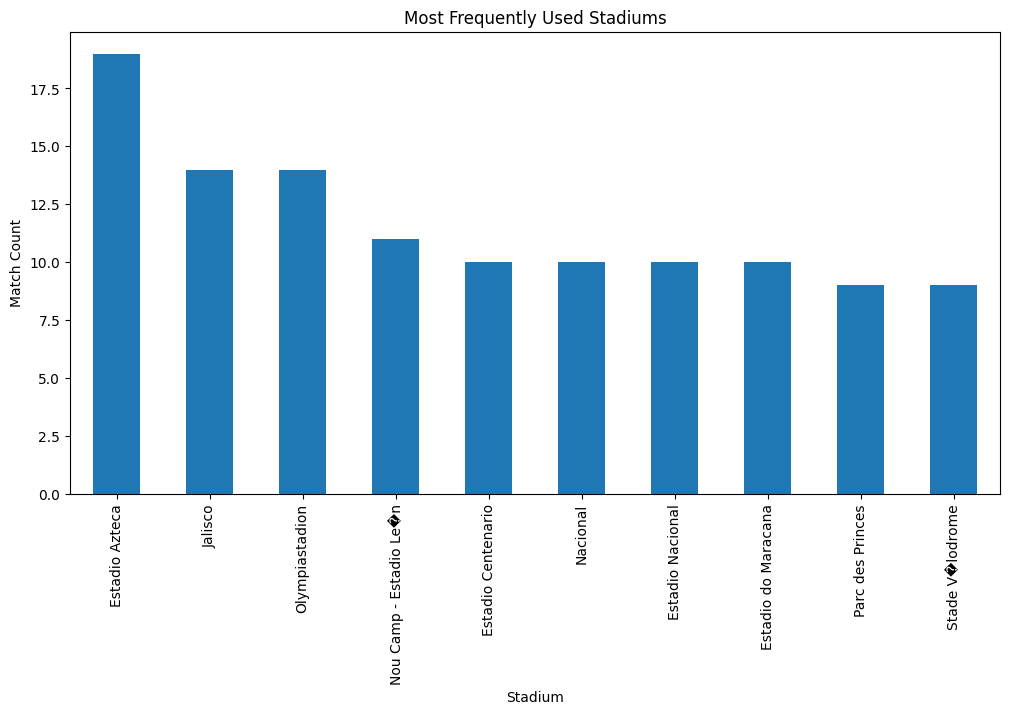

In [15]:
# EDA TASK 4 — Most Frequently Used Stadiums

usedStadiums = matches['Stadium'].value_counts().head(10)

usedStadiums

plt.figure(figsize=(12,6))

usedStadiums.plot(kind='bar')

plt.title('Most Frequently Used Stadiums')
plt.xlabel('Stadium')
plt.ylabel('Match Count')

plt.show()

In [16]:
matches['Stage'].value_counts()

Stage
Round of 16                 72
Quarter-finals              66
Group 1                     62
Group B                     60
Group A                     60
Group 2                     59
Group 3                     56
Group 4                     55
Group C                     48
Group D                     48
Group F                     48
Group E                     48
Semi-finals                 36
Group H                     30
Group G                     30
Final                       20
Match for third place       15
Group 6                     12
First round                  9
Preliminary round            8
Group 5                      6
Third place                  2
Play-off for third place     2
Name: count, dtype: int64